<div style="background-color:#84bfef; padding:20px; border-radius:10px">

# Desafío #1 | Equipo 31 | Análisis de Absentismo y Bienestar Laboral
</div>

Este notebook responde la pregunta de negocio del perfil **Analista de Absentismo y Bienestar Laboral**:

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año? ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

El análisis combina KPI, tablas y gráficos para preparar conclusiones de negocio y materiales de dashboard/presentación.


## 1. Enfoque del análisis

Se trabaja con registros de absentismo asociados a empleados (`ID`). Como un empleado puede aparecer muchas veces, se distinguen dos niveles:

- **Registro:** fila individual del dataset; útil para meses, días, motivos y horas.
- **Empleado:** agregación por `ID`; útil para medir concentración y carga acumulada.

Para los KPI principales se usa una vista depurada sin duplicados exactos. Los registros con `Absenteeism_hours = 0` se conservan para control, pero las ausencias reales se identifican con `Absenteeism_hours > 0`.


## 2. Librerías y configuración


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
COLOR_PRINCIPAL = "#2F6F73"
COLOR_SECUNDARIO = "#D68C45"
COLOR_ALERTA = "#B94E48"
COLOR_GRIS = "#6B7280"


## 3. Carga de datos


In [2]:
DATA_FILE = '../../Data/clean/clean_data_25052026.csv'
RRHH = pd.read_csv(DATA_FILE)

print("Archivo cargado:", DATA_FILE)
print("Dimensiones:", RRHH.shape)
RRHH.head()


Archivo cargado: ../../Data/clean/clean_data_25052026.csv
Dimensiones: (740, 27)


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
0,14,11.00,Sistema digestivo,11.00,Noviembre,2,Lunes,2,Primavera,155,12,14,34,284.03,97,0,1,Secundaria,2,1,0,0,95,196,25,24.70,120
1,36,13.00,Sistema musculoesquelético,4.00,Abril,4,Miércoles,4,Otoño,118,13,18,50,239.41,98,0,1,Secundaria,1,1,0,0,98,178,31,30.90,120
2,9,6.00,Sistema nervioso,7.00,Julio,3,Martes,1,Invierno,228,14,16,58,264.60,93,0,1,Secundaria,2,0,0,1,65,172,22,22.00,120
3,28,9.00,Sistema circulatorio,7.00,Julio,3,Martes,1,Invierno,225,26,9,28,230.29,92,0,1,Secundaria,1,0,0,2,69,169,24,24.20,112
4,9,12.00,Piel y tejido subcutáneo,3.00,Marzo,3,Martes,3,Verano,228,14,16,58,222.20,99,0,1,Secundaria,2,0,0,1,65,172,22,22.00,112


## 4. Diccionario de códigos


In [3]:
reason_labels = {
    1: "Enfermedades infecciosas y parasitarias",
    2: "Neoplasias",
    3: "Sangre e inmunidad",
    4: "Endocrinas, nutricionales y metabólicas",
    5: "Trastornos mentales y del comportamiento",
    6: "Sistema nervioso",
    7: "Ojo y anexos",
    8: "Oído y apófisis mastoides",
    9: "Sistema circulatorio",
    10: "Sistema respiratorio",
    11: "Sistema digestivo",
    12: "Piel y tejido subcutáneo",
    13: "Sistema musculoesquelético",
    14: "Sistema genitourinario",
    15: "Embarazo, parto y puerperio",
    16: "Afecciones perinatales",
    17: "Malformaciones congénitas",
    18: "Síntomas y hallazgos no clasificados",
    19: "Lesiones, intoxicaciones y consecuencias externas",
    20: "Causas externas de morbilidad y mortalidad",
    21: "Factores de salud y contacto sanitario",
    22: "Seguimiento de paciente",
    23: "Consulta médica",
    24: "Donación de sangre",
    25: "Examen de laboratorio",
    26: "Ausencia injustificada",
    27: "Fisioterapia",
    28: "Consulta dental",
}

month_labels = {
    1.0: "Enero", 2.0: "Febrero", 3.0: "Marzo", 4.0: "Abril", 5.0: "Mayo", 6.0: "Junio",
    7.0: "Julio", 8.0: "Agosto", 9.0: "Septiembre", 10.0: "Octubre", 11.0: "Noviembre", 12.0: "Diciembre",
}

day_labels = {2: "Lunes", 3: "Martes", 4: "Miércoles", 5: "Jueves", 6: "Viernes"}
season_labels = {1: "Invierno", 2: "Primavera", 3: "Verano", 4: "Otoño"}
education_labels = {1: "Secundaria", 2: "Grado", 3: "Posgrado", 4: "Máster/Doctorado"}

pd.DataFrame({
    "variable": ["Reason_absence", "Month_absence", "Day_week", "Seasons", "Education"],
    "uso": [
        "Motivo de ausencia según ICD y categorías administrativas",
        "Mes de ausencia",
        "Día de la semana",
        "Estación del año ajustada al criterio del notebook de limpieza",
        "Nivel educativo",
    ],
})


,variable,uso
0,Reason_absence,Motivo de ausencia según ICD y categorías admi...
1,Month_absence,Mes de ausencia
2,Day_week,Día de la semana
3,Seasons,Estación del año ajustada al criterio del note...
4,Education,Nivel educativo


## 5. Preparación analítica


In [4]:
df = RRHH.copy()

# El CSV limpio ya trae Work_load_Average_day como numérico.
df["Work_load_Average_day_num"] = df["Work_load_Average_day"]

# Alinear análisis con Data_cleaning_25052026.ipynb.
# El CSV limpio ya transforma Month_absence = 0 y Reason_absence = 0 a NaN,
# y ya remapea Seasons al criterio de estaciones usado en limpieza.

# Etiquetas legibles para gráficos y tablas.
df["Reason_label"] = df.get("Reason_absence_name", df["Reason_absence"].map(reason_labels)).fillna("Motivo no informado")
df["Month_label"] = df.get("Month_absence_name", df["Month_absence"].map(month_labels)).fillna("Mes no informado")
df["Day_label"] = df.get("Day_week_name", df["Day_week"].map(day_labels)).fillna("Día no documentado")
df["Season_label"] = df.get("Seasons_name", df["Seasons"].map(season_labels)).fillna("Estación no documentada")
df["Education_label"] = df.get("Education_name", df["Education"].map(education_labels)).fillna("Educación no documentada")
df["Tiene_ausencia"] = df["Absenteeism_hours"] > 0

# Agrupación tomada del diccionario UCI: códigos 1-21 son motivos ICD; 22-28 son seguimiento/consultas; NaN es motivo no informado.
df["Reason_group"] = np.select(
    [df["Reason_absence"].between(1, 21), df["Reason_absence"].between(22, 28), df["Reason_absence"].isna()],
    ["ICD / enfermedad", "No-ICD / consulta o gestión", "Motivo no informado"],
    default="Código no documentado",
)

def categorizar_bmi(bmi):
    if bmi < 18.5:
        return "Bajo peso"
    if bmi < 25:
        return "Peso normal"
    if bmi < 30:
        return "Sobrepeso"
    return "Obesidad"

df["BMI_category"] = df["Body_mass_index"].apply(categorizar_bmi)

filas_duplicadas = df.duplicated().sum()
df_clean = df.drop_duplicates().copy()
df_abs = df_clean[df_clean["Absenteeism_hours"] > 0].copy()
df_temporal = df_clean[df_clean["Month_absence"].between(1, 12)].copy()

resumen_preparacion = pd.DataFrame({
    "métrica": [
        "registros_originales",
        "duplicados_exactos_eliminados",
        "registros_para_análisis",
        "registros_con_ausencia_>_0h",
        "registros_con_0h",
        "empleados_ID_únicos",
        "empleados_con_ausencia_>_0h",
    ],
    "valor": [
        len(df),
        filas_duplicadas,
        len(df_clean),
        len(df_abs),
        (df_clean["Absenteeism_hours"] == 0).sum(),
        df_clean["ID"].nunique(),
        df_abs["ID"].nunique(),
    ],
})

resumen_preparacion


,métrica,valor
0,registros_originales,740
1,duplicados_exactos_eliminados,34
2,registros_para_análisis,706
3,registros_con_ausencia_>_0h,662
4,registros_con_0h,44
5,empleados_ID_únicos,36
6,empleados_con_ausencia_>_0h,33


**Decisión metodológica:** el análisis parte de `clean_data_25052026.csv`, generado por `Data_cleaning_25052026.ipynb`. Por eso `Work_load_Average_day` ya llega como numérica, `Month_absence = 0` y `Reason_absence = 0` ya llegan como `NaN`, y `Seasons` ya está remapeada según el criterio de limpieza.

## 6. KPI principales de absentismo


In [5]:
total_empleados = df_clean["ID"].nunique()
empleados_con_ausencia = df_abs["ID"].nunique()
horas_totales = df_clean["Absenteeism_hours"].sum()
registros_ausencia = len(df_abs)
horas_medias_registro = df_abs["Absenteeism_hours"].mean()
horas_medias_empleado = df_clean.groupby("ID")["Absenteeism_hours"].sum().mean()
mediana_horas_empleado = df_clean.groupby("ID")["Absenteeism_hours"].sum().median()

kpi_absentismo = pd.DataFrame({
    "KPI": [
        "Empleados únicos en el dataset",
        "Empleados con al menos una ausencia > 0h",
        "% empleados del dataset con ausencia > 0h",
        "Registros de ausencia > 0h",
        "Horas totales de absentismo",
        "Media de horas por registro con ausencia",
        "Media de horas acumuladas por empleado",
        "Mediana de horas acumuladas por empleado",
    ],
    "Valor": [
        total_empleados,
        empleados_con_ausencia,
        f"{empleados_con_ausencia / total_empleados * 100:.1f}%",
        registros_ausencia,
        horas_totales,
        round(horas_medias_registro, 2),
        round(horas_medias_empleado, 2),
        round(mediana_horas_empleado, 2),
    ],
})

kpi_absentismo


,KPI,Valor
0,Empleados únicos en el dataset,36
1,Empleados con al menos una ausencia > 0h,33
2,% empleados del dataset con ausencia > 0h,91.7%
3,Registros de ausencia > 0h,662
4,Horas totales de absentismo,5043
5,Media de horas por registro con ausencia,7.62
6,Media de horas acumuladas por empleado,140.08
7,Mediana de horas acumuladas por empleado,78.00


## 6.1 KPI según fórmulas del desafío

Esta sección replica explícitamente las **3 fórmulas solicitadas** para absentismo. Se calcula sobre la vista depurada (`df_clean`) para evitar que los duplicados exactos inflen los resultados.

- **Porcentaje de empleados ausentes (%):** empleados con al menos una ausencia > 0 horas / empleados totales del dataset.
- **Mes pico de carga por ausencias:** mes con mayor suma de horas de absentismo.
- **Motivo modal de absentismo laboral:** motivo con mayor frecuencia de registros de ausencia.


In [6]:
# 1. Porcentaje de empleados ausentes (%)
numero_empleados_ausentes = df_clean.loc[df_clean["Absenteeism_hours"] > 0, "ID"].nunique()
numero_total_empleados = df_clean["ID"].nunique()
porcentaje_empleados_ausentes = numero_empleados_ausentes / numero_total_empleados * 100

# 2. Mes pico de carga por ausencias: arg max por suma de horas.
horas_por_mes_formula = (
    df_clean[df_clean["Month_absence"].between(1, 12)]
    .groupby(["Month_absence", "Month_label"], as_index=False)["Absenteeism_hours"]
    .sum()
    .rename(columns={"Absenteeism_hours": "horas_absentismo"})
)
mes_pico_formula = horas_por_mes_formula.loc[horas_por_mes_formula["horas_absentismo"].idxmax()]

# 3. Motivo modal: arg max por frecuencia de cada motivo.
frecuencia_por_motivo_formula = (
    df_clean[df_clean["Absenteeism_hours"] > 0]
    .groupby(["Reason_absence", "Reason_label"], as_index=False)
    .size()
    .rename(columns={"size": "frecuencia"})
)
motivo_modal_formula = frecuencia_por_motivo_formula.loc[frecuencia_por_motivo_formula["frecuencia"].idxmax()]

kpi_formulas_desafio = pd.DataFrame({
    "KPI": [
        "Porcentaje de empleados ausentes (%)",
        "Mes pico de carga por ausencias",
        "Motivo modal de absentismo laboral",
    ],
    "Fórmula aplicada": [
        "empleados con >= 1 ausencia / empleados totales * 100",
        "arg max mes (suma de horas de absentismo)",
        "arg max motivo (frecuencia de registros de ausencia)",
    ],
    "Resultado": [
        f"{porcentaje_empleados_ausentes:.1f}% ({numero_empleados_ausentes}/{numero_total_empleados})",
        f"{mes_pico_formula['Month_label']} ({mes_pico_formula['horas_absentismo']:.0f} horas)",
        f"{int(motivo_modal_formula['Reason_absence'])} - {motivo_modal_formula['Reason_label']} ({int(motivo_modal_formula['frecuencia'])} registros)",
    ],
    "Lectura de negocio": [
        "Mide la extensión del absentismo entre los IDs presentes en el dataset.",
        "Identifica el mes que requiere más refuerzo de planificación por volumen de horas.",
        "Identifica el motivo más repetido, distinto del motivo que acumula más horas.",
    ],
})

kpi_formulas_desafio


,KPI,Fórmula aplicada,Resultado,Lectura de negocio
0,Porcentaje de empleados ausentes (%),empleados con >= 1 ausencia / empleados totale...,91.7% (33/36),Mide la extensión del absentismo entre los IDs...
1,Mes pico de carga por ausencias,arg max mes (suma de horas de absentismo),Marzo (755 horas),Identifica el mes que requiere más refuerzo de...
2,Motivo modal de absentismo laboral,arg max motivo (frecuencia de registros de aus...,23 - Consulta médica (142 registros),"Identifica el motivo más repetido, distinto de..."


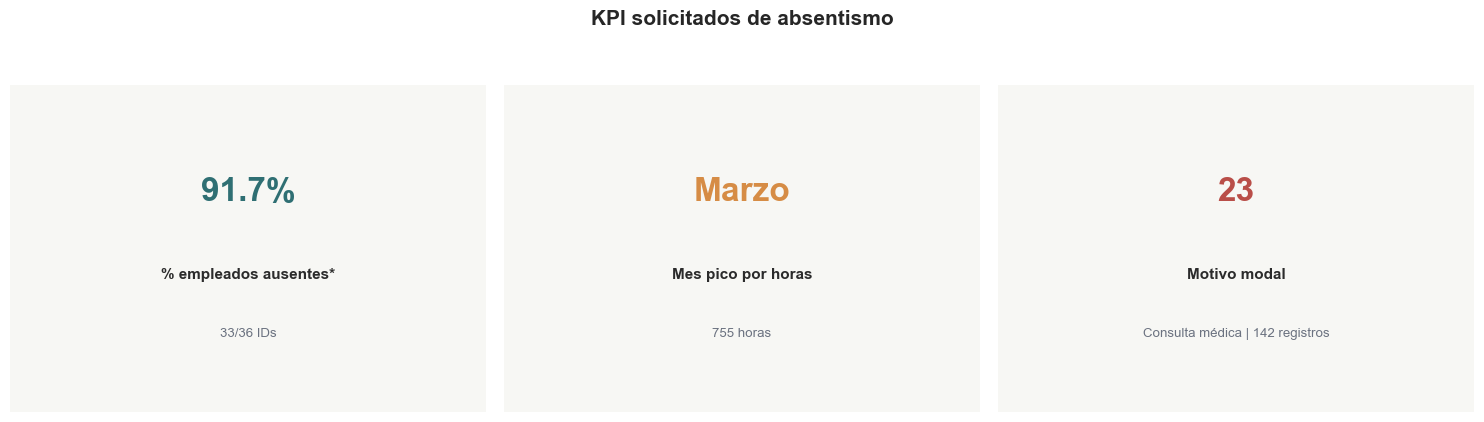

In [7]:
# Tarjetas de los 3 KPI solicitados en el enunciado.
porcentaje_empleados_ausentes_card = empleados_con_ausencia / total_empleados * 100

mes_pico_card = (
    df_clean[df_clean["Month_absence"].between(1, 12)]
    .groupby(["Month_absence", "Month_label"], as_index=False)["Absenteeism_hours"]
    .sum()
    .rename(columns={"Absenteeism_hours": "horas_totales"})
    .sort_values("horas_totales", ascending=False)
    .iloc[0]
)

motivo_modal_card = (
    df_clean[df_clean["Absenteeism_hours"] > 0]
    .groupby(["Reason_absence", "Reason_label"], as_index=False)
    .size()
    .rename(columns={"size": "frecuencia"})
    .sort_values("frecuencia", ascending=False)
    .iloc[0]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("KPI solicitados de absentismo", fontsize=15, fontweight="bold", y=1.05)

kpi_cards = [
    (
        "% empleados ausentes*",
        f"{porcentaje_empleados_ausentes_card:.1f}%",
        f"{empleados_con_ausencia}/{total_empleados} IDs",
        COLOR_PRINCIPAL,
    ),
    (
        "Mes pico por horas",
        str(mes_pico_card["Month_label"]),
        f"{mes_pico_card['horas_totales']:.0f} horas",
        COLOR_SECUNDARIO,
    ),
    (
        "Motivo modal",
        f"{int(motivo_modal_card['Reason_absence'])}",
        f"{motivo_modal_card['Reason_label']} | {int(motivo_modal_card['frecuencia'])} registros",
        COLOR_ALERTA,
    ),
]

for ax, (titulo, valor, detalle, color) in zip(axes, kpi_cards):
    ax.set_facecolor("#F7F7F4")
    ax.text(0.5, 0.67, valor, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.42, titulo, ha="center", va="center", fontsize=11, fontweight="bold", color="#2B2B2B")
    ax.text(0.5, 0.24, detalle, ha="center", va="center", fontsize=9.5, color=COLOR_GRIS, wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estas tarjetas resumen los **3 KPI solicitados en el enunciado**: porcentaje de empleados ausentes, mes pico por horas de ausencia y motivo modal por frecuencia. Sirven como lectura ejecutiva antes de entrar en los gráficos de detalle: dimensión del problema, momento crítico del año y causa más repetida.

### Lectura de los KPI del enunciado

Estos KPI responden directamente a la pregunta semanal. El porcentaje dimensiona la magnitud del absentismo, el mes pico permite anticipar refuerzos y el motivo modal identifica la causa más frecuente. Conviene mantener separados el **motivo modal por frecuencia** y el **motivo con más horas**, porque pueden responder a problemas distintos: recurrencia frente a severidad.

## 7. Variación mensual: ¿cuándo se concentra el absentismo?


In [8]:
absentismo_por_mes = (
    df_temporal
    .groupby(["Month_absence", "Month_label"], as_index=False)
    .agg(
        registros=("ID", "count"),
        registros_ausencia=("Tiene_ausencia", "sum"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
        carga_media=("Work_load_Average_day_num", "mean"),
        hit_target_medio=("Hit_target", "mean"),
    )
    .sort_values("Month_absence")
)

absentismo_por_mes["%_horas_anuales"] = absentismo_por_mes["horas_totales"] / absentismo_por_mes["horas_totales"].sum() * 100
absentismo_por_mes.round(2)


,Month_absence,Month_label,registros,registros_ausencia,empleados_unicos,horas_totales,horas_media,carga_media,hit_target_medio,%_horas_anuales
0,1.00,Enero,45,44,13,212,4.71,315.49,96.56,4.20
1,2.00,Febrero,62,62,19,269,4.34,272.17,97.32,5.33
2,3.00,Marzo,83,79,22,755,9.10,270.37,97.34,14.97
3,4.00,Abril,50,49,21,476,9.52,276.57,94.82,9.44
4,5.00,Mayo,61,55,24,393,6.44,276.77,97.16,7.79
5,6.00,Junio,54,51,19,411,7.61,298.01,95.06,8.15
6,7.00,Julio,65,63,23,730,11.23,250.27,95.05,14.48
7,8.00,Agosto,54,54,21,288,5.33,238.01,92.94,5.71
8,9.00,Septiembre,52,43,17,291,5.60,265.04,86.92,5.77
9,10.00,Octubre,69,60,19,344,4.99,269.36,90.32,6.82


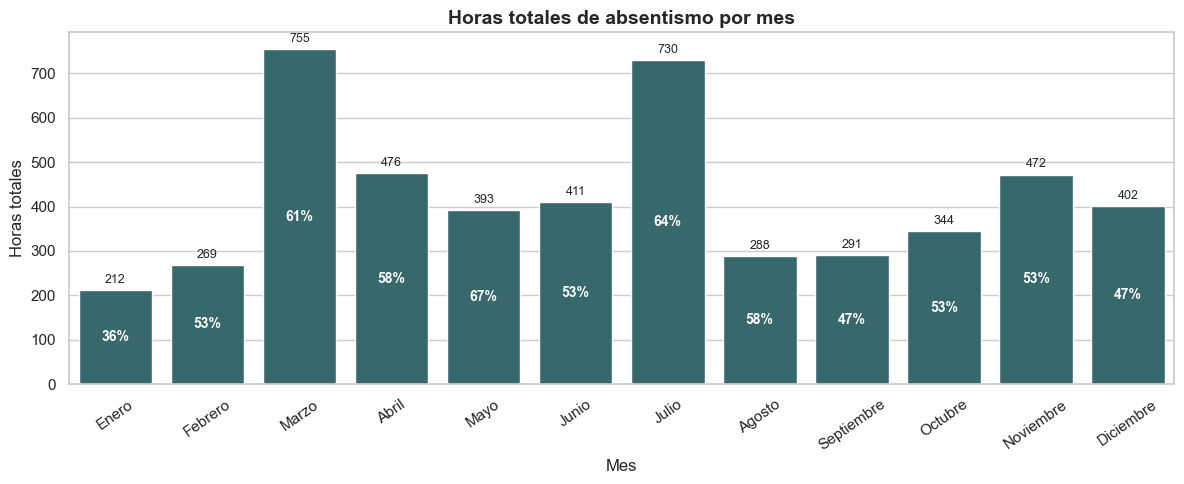

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_data = absentismo_por_mes.copy()
plot_data["%_ids_ausentes"] = plot_data["empleados_unicos"] / total_empleados * 100

sns.barplot(
    data=plot_data,
    x="Month_label",
    y="horas_totales",
    color=COLOR_PRINCIPAL,
    ax=ax,
)

ax.set_title("Horas totales de absentismo por mes", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Horas totales")
ax.tick_params(axis="x", rotation=35)

# Etiqueta superior: horas totales. Etiqueta interior: % de IDs con ausencia en el mes.
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

for patch, pct in zip(ax.patches, plot_data["%_ids_ausentes"]):
    altura = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        altura / 2,
        f"{pct:.0f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico responde a **cómo varía el absentismo a lo largo del año**. La cifra superior de cada barra muestra las **horas totales** del mes, mientras que el porcentaje en blanco dentro de la barra indica qué proporción de los **36 IDs del dataset** tuvo al menos una ausencia registrada ese mes. Así se puede distinguir entre meses con muchas horas concentradas y meses con más empleados afectados.

El pico principal aparece en **marzo (755 horas)** y el segundo en **julio (730 horas)**; después destacan abril, noviembre y junio. Para planificación, estos meses deberían revisarse antes de que lleguen: cobertura, turnos, vacaciones, refuerzos y medidas preventivas.


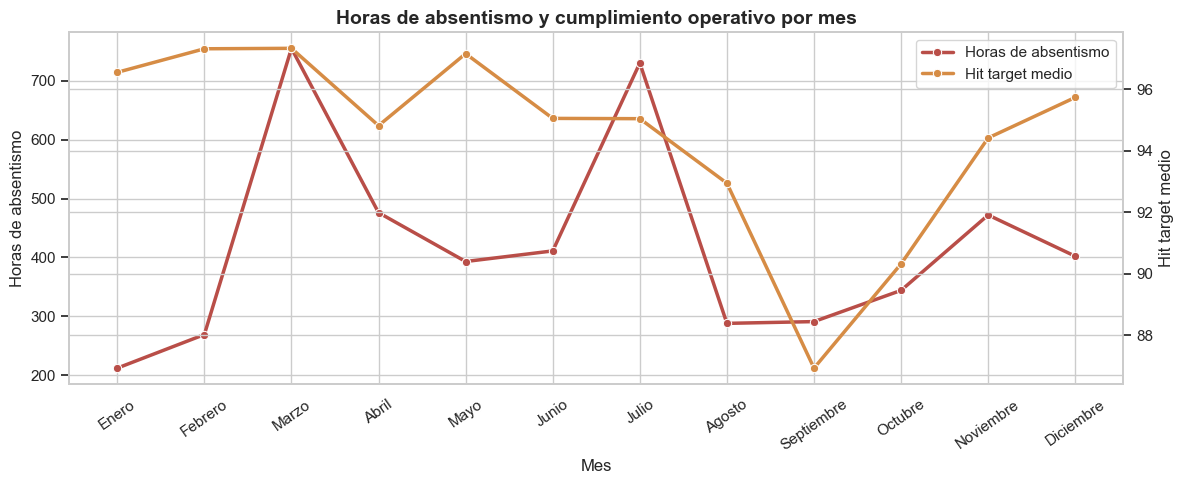

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

sns.lineplot(
    data=absentismo_por_mes,
    x="Month_label",
    y="horas_totales",
    marker="o",
    linewidth=2.5,
    color=COLOR_ALERTA,
    ax=ax1,
    label="Horas de absentismo",
)
sns.lineplot(
    data=absentismo_por_mes,
    x="Month_label",
    y="hit_target_medio",
    marker="o",
    linewidth=2.5,
    color=COLOR_SECUNDARIO,
    ax=ax2,
    label="Hit target medio",
)

ax1.set_title("Horas de absentismo y cumplimiento operativo por mes", fontsize=14, fontweight="bold")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Horas de absentismo")
ax2.set_ylabel("Hit target medio")
ax1.tick_params(axis="x", rotation=35)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
ax2.get_legend().remove()

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico conecta absentismo con **continuidad operativa**. Sirve para comprobar si los meses con más horas coinciden con peor `Hit_target`, pero en estos datos la relación visual no parece fuerte ni lineal: marzo tiene muchas horas y un `Hit_target` alto, mientras septiembre y octubre tienen menor `Hit_target` sin ser los meses de más horas. Por eso este gráfico no explica el absentismo por sí solo; funciona mejor como señal de seguimiento operativo mes a mes.


## 8. Motivos de ausencia: ¿qué explica más horas?


In [11]:
absentismo_por_motivo = (
    df_clean
    .groupby(["Reason_absence", "Reason_label"], as_index=False)
    .agg(
        registros=("ID", "count"),
        registros_ausencia=("Tiene_ausencia", "sum"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
    )
    .sort_values("horas_totales", ascending=False)
)

absentismo_por_motivo["%_horas"] = absentismo_por_motivo["horas_totales"] / absentismo_por_motivo["horas_totales"].sum() * 100
absentismo_por_motivo.round(2)


,Reason_absence,Reason_label,registros,registros_ausencia,empleados_unicos,horas_totales,horas_media,%_horas
12,13.00,Sistema musculoesquelético,55,55,18,842,15.31,16.70
18,19.00,"Lesiones, intoxicaciones y consecuencias externas",40,40,17,729,18.23,14.46
21,23.00,Consulta médica,142,142,24,408,2.87,8.09
26,28.00,Consulta dental,108,108,17,329,3.05,6.52
10,11.00,Sistema digestivo,26,26,14,297,11.42,5.89
20,22.00,Seguimiento de paciente,37,37,12,285,7.70,5.65
9,10.00,Sistema respiratorio,25,25,13,276,11.04,5.47
24,26.00,Ausencia injustificada,33,33,11,240,7.27,4.76
17,18.00,Síntomas y hallazgos no clasificados,21,21,12,217,10.33,4.30
11,12.00,Piel y tejido subcutáneo,8,8,7,187,23.38,3.71


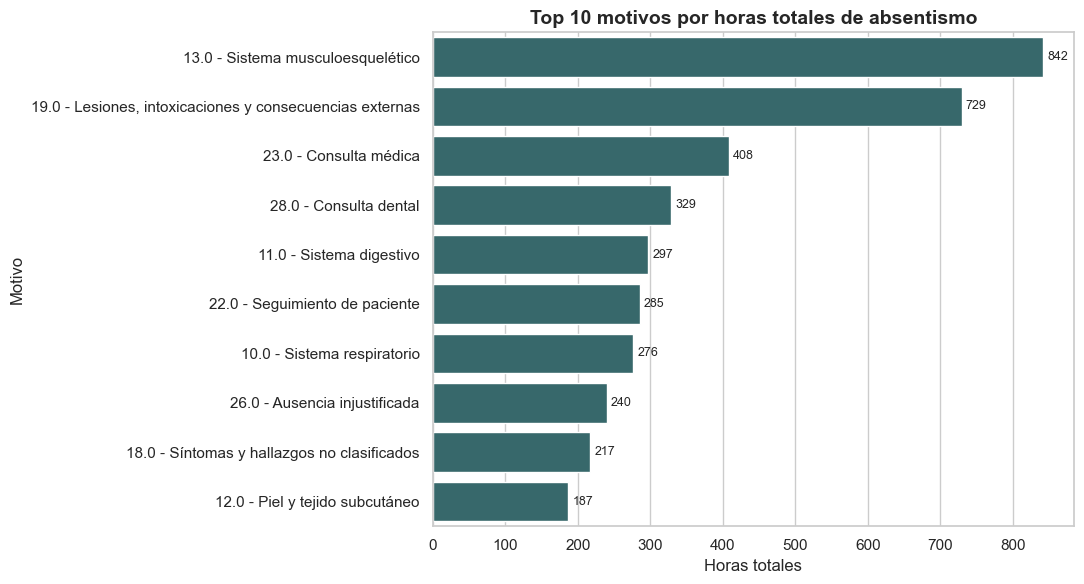

In [12]:
top_motivos = absentismo_por_motivo.head(10).copy()
top_motivos["motivo_corto"] = top_motivos["Reason_absence"].astype(str) + " - " + top_motivos["Reason_label"]

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_motivos,
    y="motivo_corto",
    x="horas_totales",
    color=COLOR_PRINCIPAL,
    ax=ax,
)

ax.set_title("Top 10 motivos por horas totales de absentismo", fontsize=14, fontweight="bold")
ax.set_xlabel("Horas totales")
ax.set_ylabel("Motivo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico responde a **qué motivos explican más horas de absentismo**. El código **13, sistema musculoesquelético**, lidera con **842 horas**, seguido del **19, lesiones/intoxicaciones/consecuencias externas**, con **729 horas**. Para RRHH, esto apunta a acciones preventivas concretas: ergonomía, seguridad laboral, revisión de tareas físicas y seguimiento de casos recurrentes.


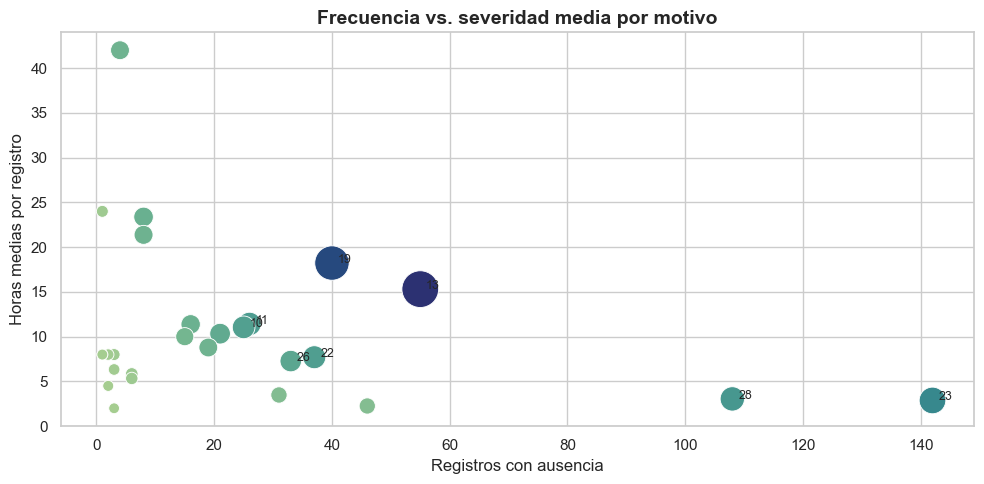

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=absentismo_por_motivo,
    x="registros_ausencia",
    y="horas_media",
    size="horas_totales",
    hue="horas_totales",
    sizes=(60, 700),
    palette="crest",
    ax=ax,
    legend=False,
)

for _, row in absentismo_por_motivo.head(8).iterrows():
    ax.text(row["registros_ausencia"] + 1, row["horas_media"], str(int(row["Reason_absence"])), fontsize=9)

ax.set_title("Frecuencia vs. severidad media por motivo", fontsize=14, fontweight="bold")
ax.set_xlabel("Registros con ausencia")
ax.set_ylabel("Horas medias por registro")
plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico separa **frecuencia** y **severidad**. Algunos motivos aparecen muchas veces pero con pocas horas medias, como consultas médicas o dentales; otros aparecen menos, pero generan ausencias más largas. Esta distinción ayuda a decidir si la respuesta debe ser administrativa, preventiva o de sustitución operativa.



## 8.1 Motivos ICD vs no-ICD

El repositorio externo revisado propone separar los motivos incluidos en la clasificación ICD de los motivos administrativos o de consulta (`22-28`). Esta agrupación sí es útil para negocio porque permite distinguir entre absentismo asociado a enfermedad/lesión y ausencias de seguimiento, consultas o gestiones.


In [14]:

absentismo_por_grupo_motivo = (
    df_clean
    .groupby("Reason_group", as_index=False)
    .agg(
        registros=("ID", "count"),
        registros_ausencia=("Tiene_ausencia", "sum"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
    )
    .sort_values("horas_totales", ascending=False)
)

absentismo_por_grupo_motivo["%_horas"] = (
    absentismo_por_grupo_motivo["horas_totales"] / absentismo_por_grupo_motivo["horas_totales"].sum() * 100
)

absentismo_por_grupo_motivo.round(2)


,Reason_group,registros,registros_ausencia,empleados_unicos,horas_totales,horas_media,%_horas
0,ICD / enfermedad,262,262,33,3543,13.52,70.26
2,No-ICD / consulta o gestión,401,400,31,1500,3.74,29.74
1,Motivo no informado,43,0,22,0,0.00,0.00


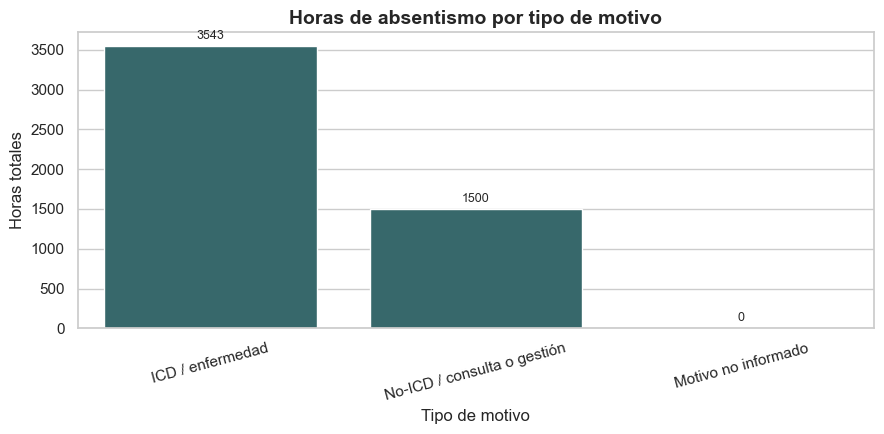

In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=absentismo_por_grupo_motivo,
    x="Reason_group",
    y="horas_totales",
    color=COLOR_PRINCIPAL,
    ax=ax,
)

ax.set_title("Horas de absentismo por tipo de motivo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de motivo")
ax.set_ylabel("Horas totales")
ax.tick_params(axis="x", rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()



### Lectura del gráfico

Esta agrupación ayuda a responder **qué tipo de absentismo pesa más**. Si predominan las horas ICD, la respuesta de RRHH debe orientarse a prevención de salud, ergonomía y seguridad laboral; si pesan mucho las categorías no-ICD, puede haber margen para gestionar citas, consultas o procesos administrativos sin afectar tanto la operación. Es una lectura más accionable que mirar solo códigos sueltos.


## 9. Día de la semana y estación: señales para planificación


In [16]:
absentismo_por_dia = (
    df_clean
    .groupby(["Day_week", "Day_label"], as_index=False)
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
    )
    .sort_values("Day_week")
)

absentismo_por_estacion = (
    df_clean
    .groupby(["Seasons", "Season_label"], as_index=False)
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
    )
    .sort_values("Seasons")
)

display(absentismo_por_dia.round(2))
display(absentismo_por_estacion.round(2))


,Day_week,Day_label,registros,empleados_unicos,horas_totales,horas_media
0,2,Lunes,158,29,1483,9.39
1,3,Martes,150,28,1221,8.14
2,4,Miércoles,144,29,1081,7.51
3,5,Jueves,119,29,539,4.53
4,6,Viernes,135,26,719,5.33


,Seasons,Season_label,registros,empleados_unicos,horas_totales,horas_media
0,1,Invierno,167,30,1236,7.40
1,2,Primavera,189,25,1221,6.46
2,3,Verano,173,30,1107,6.40
3,4,Otoño,177,31,1479,8.36


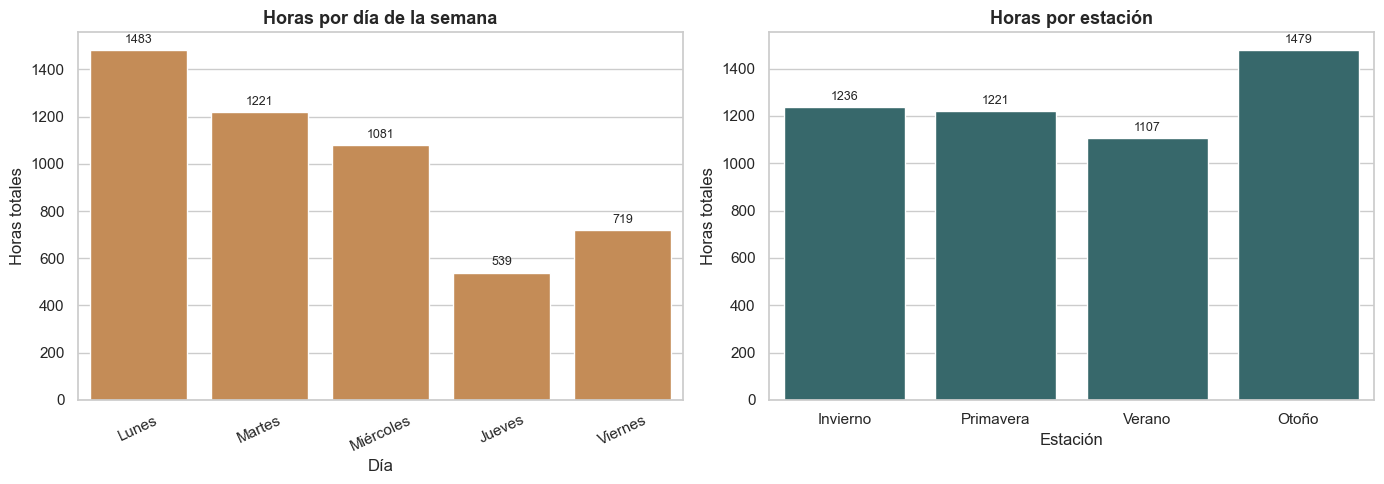

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=absentismo_por_dia, x="Day_label", y="horas_totales", color=COLOR_SECUNDARIO, ax=axes[0])
axes[0].set_title("Horas por día de la semana", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Horas totales")
axes[0].tick_params(axis="x", rotation=25)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

sns.barplot(data=absentismo_por_estacion, x="Season_label", y="horas_totales", color=COLOR_PRINCIPAL, ax=axes[1])
axes[1].set_title("Horas por estación", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Estación")
axes[1].set_ylabel("Horas totales")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estos gráficos ayudan a anticipar necesidades de cobertura. El absentismo se concentra más en **lunes (1.483 horas)**, seguido de martes y miércoles, por lo que el inicio de semana merece especial atención en la planificación. En `Seasons`, se usa el remapeo aplicado en `Data_cleaning_25052026.ipynb`, por lo que las etiquetas representan estaciones en calendario austral.

## 10. Concentración por empleado


In [18]:
absentismo_por_empleado = (
    df_clean
    .groupby("ID", as_index=False)
    .agg(
        registros=("ID", "count"),
        registros_ausencia=("Tiene_ausencia", "sum"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
        edad=("Age", "first"),
        antiguedad=("Service_time", "first"),
        distancia_km=("Distance_Residence_Work", "first"),
        educacion=("Education_label", "first"),
        hit_target_medio=("Hit_target", "mean"),
    )
    .sort_values("horas_totales", ascending=False)
)

absentismo_por_empleado["%_horas"] = absentismo_por_empleado["horas_totales"] / absentismo_por_empleado["horas_totales"].sum() * 100
absentismo_por_empleado["%_horas_acum"] = absentismo_por_empleado["%_horas"].cumsum()
absentismo_por_empleado.head(10).round(2)


,ID,registros,registros_ausencia,horas_totales,horas_media,edad,antiguedad,distancia_km,educacion,hit_target_medio,%_horas,%_horas_acum
13,14,29,29,476,16.41,34,14,12,Secundaria,95.69,9.44,9.44
10,11,40,38,450,11.25,33,13,36,Secundaria,93.85,8.92,18.36
2,3,97,96,444,4.58,38,18,51,Secundaria,94.76,8.80,27.17
27,28,75,73,343,4.57,28,9,26,Secundaria,94.89,6.80,33.97
33,34,50,49,333,6.66,37,10,10,Secundaria,94.62,6.60,40.57
35,36,34,28,311,9.15,50,18,13,Secundaria,94.32,6.17,46.74
19,20,42,39,306,7.29,36,11,50,Secundaria,94.57,6.07,52.81
8,9,8,8,262,32.75,58,16,14,Secundaria,95.88,5.20,58.00
14,15,36,34,251,6.97,40,12,31,Secundaria,92.42,4.98,62.98
23,24,28,27,251,8.96,41,16,25,Secundaria,94.14,4.98,67.96


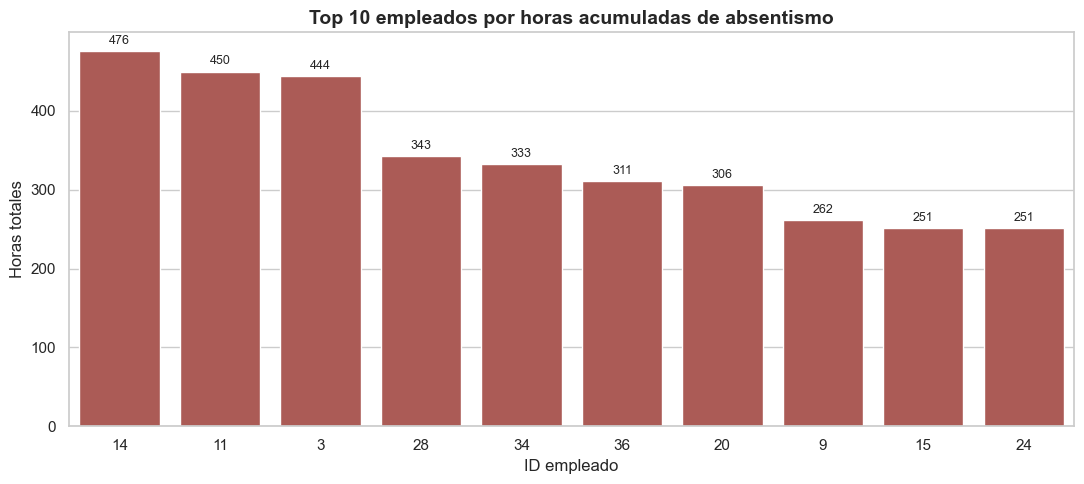

In [19]:
top_empleados = absentismo_por_empleado.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_empleados, x="ID", y="horas_totales", color=COLOR_ALERTA, order=top_empleados["ID"], ax=ax)
ax.set_title("Top 10 empleados por horas acumuladas de absentismo", fontsize=14, fontweight="bold")
ax.set_xlabel("ID empleado")
ax.set_ylabel("Horas totales")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico responde a la **concentración del absentismo por empleado**. Los 10 IDs con más horas acumulan cerca del **68%** de las horas totales, y los 5 primeros alrededor del **41%**. Para negocio, esto sugiere dos líneas de acción distintas: planificación agregada para los picos temporales y revisión individual confidencial para casos con carga acumulada alta.


In [20]:
participacion_top_5 = absentismo_por_empleado.head(5)["%_horas"].sum()
participacion_top_10 = absentismo_por_empleado.head(10)["%_horas"].sum()

concentracion = pd.DataFrame({
    "grupo": ["Top 5 empleados", "Top 10 empleados", "Resto"],
    "% horas totales": [
        participacion_top_5,
        participacion_top_10,
        100 - participacion_top_10,
    ],
})

concentracion.round(2)


,grupo,% horas totales
0,Top 5 empleados,40.57
1,Top 10 empleados,67.96
2,Resto,32.04


## 11. Variables operativas: carga, hit target y absentismo


In [21]:
correlaciones_operativas = (
    df_clean[["Absenteeism_hours", "Work_load_Average_day_num", "Hit_target", "Service_time", "Distance_Residence_Work", "Age", "Body_mass_index"]]
    .corr(numeric_only=True)[["Absenteeism_hours"]]
    .sort_values("Absenteeism_hours", ascending=False)
)

correlaciones_operativas.round(3)


,Absenteeism_hours
Absenteeism_hours,1.00
Age,0.07
Hit_target,0.03
Service_time,0.03
Work_load_Average_day_num,0.02
Body_mass_index,-0.05
Distance_Residence_Work,-0.09


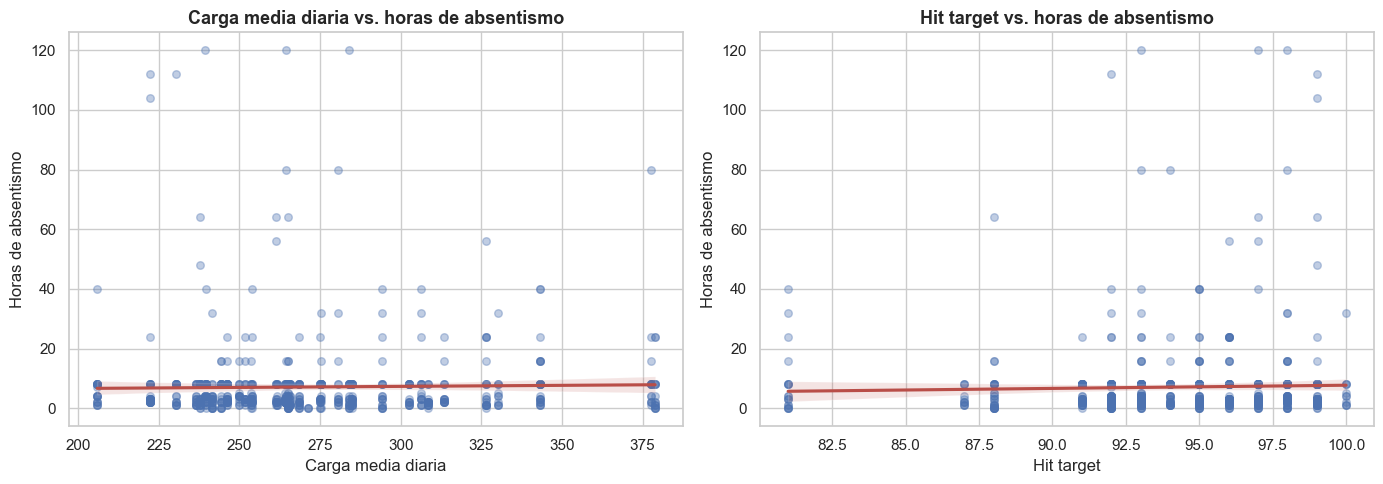

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_clean,
    x="Work_load_Average_day_num",
    y="Absenteeism_hours",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"color": COLOR_ALERTA},
    ax=axes[0],
)
axes[0].set_title("Carga media diaria vs. horas de absentismo", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Carga media diaria")
axes[0].set_ylabel("Horas de absentismo")

sns.regplot(
    data=df_clean,
    x="Hit_target",
    y="Absenteeism_hours",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"color": COLOR_ALERTA},
    ax=axes[1],
)
axes[1].set_title("Hit target vs. horas de absentismo", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hit target")
axes[1].set_ylabel("Horas de absentismo")

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estos gráficos evalúan si `Work_load_Average_day` o `Hit_target` explican directamente las horas de absentismo. La relación observada es muy débil, así que no conviene afirmar que más carga o mejor/peor cumplimiento causen más ausencias con este análisis descriptivo. Su valor está en incorporarlos como variables de control para detectar meses operativamente sensibles.



## 11.1 BMI categorizado como variable exploratoria de bienestar

Del repositorio externo también sirve la idea de categorizar el `Body_mass_index` con los cortes internacionales habituales. En este análisis se usa solo como variable exploratoria de bienestar: puede ayudar a segmentar, pero no debe presentarse como causa del absentismo.


In [23]:

bmi_absentismo = (
    df_clean
    .groupby("BMI_category", as_index=False)
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean"),
    )
)

orden_bmi = ["Bajo peso", "Peso normal", "Sobrepeso", "Obesidad"]
bmi_absentismo["BMI_category"] = pd.Categorical(bmi_absentismo["BMI_category"], categories=orden_bmi, ordered=True)
bmi_absentismo = bmi_absentismo.sort_values("BMI_category")

bmi_absentismo.round(2)


,BMI_category,registros,empleados_unicos,horas_totales,horas_media
1,Peso normal,254,13,1712,6.74
2,Sobrepeso,225,14,1910,8.49
0,Obesidad,227,9,1421,6.26


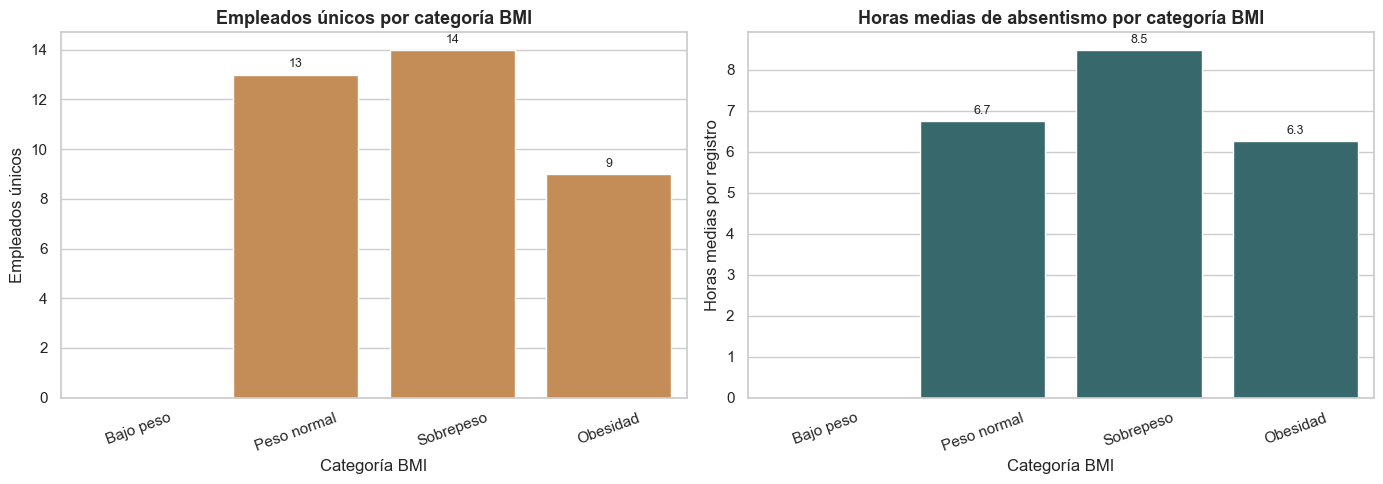

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=bmi_absentismo, x="BMI_category", y="empleados_unicos", color=COLOR_SECUNDARIO, ax=axes[0])
axes[0].set_title("Empleados únicos por categoría BMI", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Categoría BMI")
axes[0].set_ylabel("Empleados únicos")
axes[0].tick_params(axis="x", rotation=20)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

sns.barplot(data=bmi_absentismo, x="BMI_category", y="horas_media", color=COLOR_PRINCIPAL, ax=axes[1])
axes[1].set_title("Horas medias de absentismo por categoría BMI", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Categoría BMI")
axes[1].set_ylabel("Horas medias por registro")
axes[1].tick_params(axis="x", rotation=20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()



### Lectura del gráfico

La categorización de BMI aporta contexto de bienestar, pero no debe convertirse en una conclusión causal. Sirve para comprobar si algún grupo concentra más horas medias y para decidir si merece la pena incluir esta variable en el dashboard o dejarla como análisis complementario. Si se presenta, conviene hacerlo con lenguaje prudente y agregado.


## 12. Matriz de prioridad para anticipación


In [25]:
# Prioridad mensual: combina horas absolutas, número de empleados afectados y caída relativa de hit target.
prioridad_mensual = absentismo_por_mes.copy()
prioridad_mensual["rank_horas"] = prioridad_mensual["horas_totales"].rank(ascending=False, method="dense")
prioridad_mensual["rank_empleados"] = prioridad_mensual["empleados_unicos"].rank(ascending=False, method="dense")
prioridad_mensual["rank_hit_bajo"] = prioridad_mensual["hit_target_medio"].rank(ascending=True, method="dense")
prioridad_mensual["score_prioridad"] = (
    prioridad_mensual["rank_horas"] * 0.50
    + prioridad_mensual["rank_empleados"] * 0.30
    + prioridad_mensual["rank_hit_bajo"] * 0.20
)

prioridad_mensual = prioridad_mensual.sort_values("score_prioridad").reset_index(drop=True)
prioridad_mensual[[
    "Month_label", "horas_totales", "empleados_unicos", "hit_target_medio", "%_horas_anuales", "score_prioridad"
]].head(6).round(2)


,Month_label,horas_totales,empleados_unicos,hit_target_medio,%_horas_anuales,score_prioridad
0,Julio,730,23,95.05,14.48,2.80
1,Abril,476,21,94.82,9.44,3.70
2,Marzo,755,22,97.34,14.97,3.80
3,Noviembre,472,19,94.42,9.36,4.30
4,Junio,411,19,95.06,8.15,5.40
5,Mayo,393,24,97.16,7.79,5.80


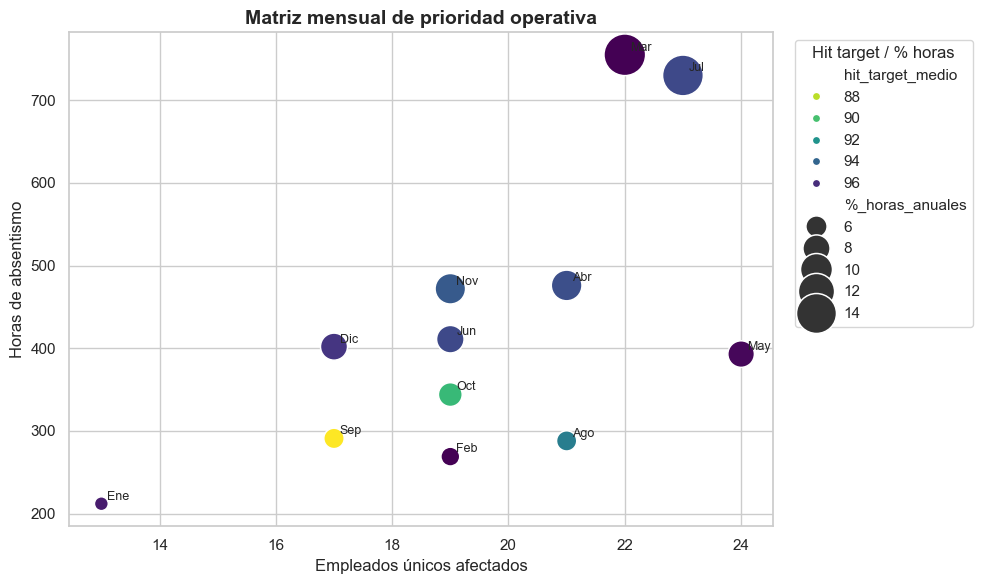

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=prioridad_mensual,
    x="empleados_unicos",
    y="horas_totales",
    size="%_horas_anuales",
    hue="hit_target_medio",
    palette="viridis_r",
    sizes=(100, 900),
    ax=ax,
)

for _, row in prioridad_mensual.iterrows():
    ax.text(row["empleados_unicos"] + 0.1, row["horas_totales"] + 5, row["Month_label"][:3], fontsize=9)

ax.set_title("Matriz mensual de prioridad operativa", fontsize=14, fontweight="bold")
ax.set_xlabel("Empleados únicos afectados")
ax.set_ylabel("Horas de absentismo")
ax.legend(title="Hit target / % horas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Lectura del gráfico

Esta matriz traduce el análisis a una herramienta de decisión. Los meses situados arriba y a la derecha combinan más horas y más empleados afectados, por lo que deberían priorizarse en la planificación de recursos. Es la visualización más directamente conectada con la pregunta de **cómo anticiparse para garantizar continuidad operativa**.


## 13. Respuesta a las preguntas de negocio


In [27]:
mes_pico = absentismo_por_mes.sort_values("horas_totales", ascending=False).iloc[0]
mes_segundo = absentismo_por_mes.sort_values("horas_totales", ascending=False).iloc[1]
motivo_pico = absentismo_por_motivo.iloc[0]
motivo_modal_conclusion = motivo_modal_formula
dia_pico = absentismo_por_dia.sort_values("horas_totales", ascending=False).iloc[0]
estacion_pico = absentismo_por_estacion.sort_values("horas_totales", ascending=False).iloc[0]

top3_meses = ", ".join(absentismo_por_mes.sort_values("horas_totales", ascending=False).head(3)["Month_label"].tolist())
top3_motivos = ", ".join(
    absentismo_por_motivo.head(3).apply(lambda r: f"{int(r['Reason_absence'])} ({r['Reason_label']})", axis=1).tolist()
)

respuesta = f"""
### Conclusiones ejecutivas

**Magnitud:** en la vista depurada hay **{horas_totales:.0f} horas de absentismo** y **{registros_ausencia} registros con más de 0 horas**. El dataset contiene **{total_empleados} empleados únicos**, de los cuales **{empleados_con_ausencia} ({empleados_con_ausencia / total_empleados * 100:.1f}%)** tienen al menos una ausencia registrada. Esta cifra describe solo los IDs presentes en la tabla, no necesariamente toda la plantilla de la empresa.

**Variación anual:** el mes con mayor carga es **{mes_pico['Month_label']}**, con **{mes_pico['horas_totales']:.0f} horas**, seguido de **{mes_segundo['Month_label']}** con **{mes_segundo['horas_totales']:.0f} horas**. Los tres meses de mayor presión son: **{top3_meses}**.

**Motivos principales:** el motivo modal por frecuencia es **{int(motivo_modal_conclusion['Reason_absence'])} - {motivo_modal_conclusion['Reason_label']}**, con **{int(motivo_modal_conclusion['frecuencia'])} registros**. En cambio, el motivo que más horas acumula es **{int(motivo_pico['Reason_absence'])} - {motivo_pico['Reason_label']}**, con **{motivo_pico['horas_totales']:.0f} horas**. Los tres motivos más relevantes por horas son: **{top3_motivos}**.

**Planificación operativa:** el día con más horas es **{dia_pico['Day_label']}** y la estación con más horas es **{estacion_pico['Season_label']}**. Para anticiparse, RRHH debería reforzar cobertura en los meses pico, revisar medidas preventivas para los motivos clínicos más costosos y monitorizar semanalmente los meses con mayor score de prioridad.
"""

display(Markdown(respuesta))



### Conclusiones ejecutivas

**Magnitud:** en la vista depurada hay **5043 horas de absentismo** y **662 registros con más de 0 horas**. El dataset contiene **36 empleados únicos**, de los cuales **33 (91.7%)** tienen al menos una ausencia registrada. Esta cifra describe solo los IDs presentes en la tabla, no necesariamente toda la plantilla de la empresa.

**Variación anual:** el mes con mayor carga es **Marzo**, con **755 horas**, seguido de **Julio** con **730 horas**. Los tres meses de mayor presión son: **Marzo, Julio, Abril**.

**Motivos principales:** el motivo modal por frecuencia es **23 - Consulta médica**, con **142 registros**. En cambio, el motivo que más horas acumula es **13 - Sistema musculoesquelético**, con **842 horas**. Los tres motivos más relevantes por horas son: **13 (Sistema musculoesquelético), 19 (Lesiones, intoxicaciones y consecuencias externas), 23 (Consulta médica)**.

**Planificación operativa:** el día con más horas es **Lunes** y la estación con más horas es **Otoño**. Para anticiparse, RRHH debería reforzar cobertura en los meses pico, revisar medidas preventivas para los motivos clínicos más costosos y monitorizar semanalmente los meses con mayor score de prioridad.


## 14. Recomendaciones de negocio

1. **Planificar refuerzos antes de los meses pico:** preparar cobertura temporal o redistribución de turnos antes de marzo y julio, que concentran más horas.
2. **Actuar sobre los motivos de mayor impacto:** priorizar prevención ergonómica y salud musculoesquelética, además de revisar casos de lesiones y consultas médicas frecuentes.
3. **Separar seguimiento individual y planificación agregada:** los empleados con más horas acumuladas requieren análisis confidencial caso a caso; los picos mensuales requieren decisiones de capacidad.
4. **Crear alertas tempranas:** usar la matriz mensual de prioridad para marcar meses con muchas horas, muchos empleados afectados o `Hit_target` bajo.
5. **Validar el denominador de plantilla:** para convertir el KPI en tasa real de absentismo de empresa, hace falta conocer el total de empleados activos, incluidos los que no tienen registros.


## 15. Tablas listas para dashboard


In [28]:
tablas_dashboard = {
    "kpi_absentismo": kpi_absentismo,
    "kpi_formulas_desafio": kpi_formulas_desafio,
    "absentismo_por_mes": absentismo_por_mes.round(2),
    "absentismo_por_motivo": absentismo_por_motivo.round(2),
    "absentismo_por_grupo_motivo": absentismo_por_grupo_motivo.round(2),
    "absentismo_por_dia": absentismo_por_dia.round(2),
    "absentismo_por_estacion": absentismo_por_estacion.round(2),
    "absentismo_por_empleado": absentismo_por_empleado.round(2),
    "prioridad_mensual": prioridad_mensual.round(2),
    "bmi_absentismo": bmi_absentismo.round(2),
}

for nombre, tabla in tablas_dashboard.items():
    print(f"{nombre}: {tabla.shape[0]} filas x {tabla.shape[1]} columnas")


kpi_absentismo: 8 filas x 2 columnas
kpi_formulas_desafio: 3 filas x 4 columnas
absentismo_por_mes: 12 filas x 10 columnas
absentismo_por_motivo: 27 filas x 8 columnas
absentismo_por_grupo_motivo: 3 filas x 7 columnas
absentismo_por_dia: 5 filas x 6 columnas
absentismo_por_estacion: 4 filas x 6 columnas
absentismo_por_empleado: 36 filas x 12 columnas
prioridad_mensual: 12 filas x 14 columnas
bmi_absentismo: 3 filas x 5 columnas
